# Regresión lineal del precio de la vivienda en EE. UU.

## Primer de regresión lineal

En estadística, la regresión lineal es un enfoque lineal para modelar la relación entre una variable dependiente escalar y y una o más variables explicativas (o variables independientes) denominadas X. El caso de una variable explicativa se denomina regresión lineal simple. Para más de una variable explicativa, el proceso se denomina regresión lineal múltiple.

Los modelos de regresión lineal a menudo se ajustan utilizando el enfoque de mínimos cuadrados, pero también pueden ajustarse de otras formas, como minimizando la "falta de ajuste" en alguna otra norma (como con la regresión de desviaciones mínimas absolutas), o minimizando una penalización. versión de la función de pérdida por mínimos cuadrados como en la regresión de crestas (penalización de $L_2$ -norm) y lazo (penalización de $L_1$ -norm). Por el contrario, el enfoque de mínimos cuadrados se puede utilizar para ajustar modelos que no son modelos lineales. Por lo tanto, aunque los términos "mínimos cuadrados" y "modelo lineal" están estrechamente relacionados, no son sinónimos.

### Importando paquetes y el conjunto de datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [42]:
# df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/USA_Housing.csv")
df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv")

df.head()  # vemos los 5 primeros datos del dataframe

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


### Consultar información básica sobre el conjunto de datos

**El método 'info()'los tipos y números de datos**

In [173]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Age                 10000 non-null  int64         
 2   Gender              10000 non-null  object        
 3   Blood Type          10000 non-null  object        
 4   Medical Condition   10000 non-null  object        
 5   Date of Admission   10000 non-null  datetime64[ns]
 6   Doctor              10000 non-null  object        
 7   Hospital            10000 non-null  object        
 8   Insurance Provider  10000 non-null  object        
 9   Billing Amount      10000 non-null  float64       
 10  Room Number         10000 non-null  int64         
 11  Admission Type      10000 non-null  object        
 12  Discharge Date      10000 non-null  datetime64[ns]
 13  Medication          10000 non-null  object     

**El método 'describe()' obtiene un resumen de estadísticas de las características del conjunto de datos**

In [174]:
df.describe()


,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,10000.000000,10000,10000.000000,10000.000000,10000,10000.000000
mean,51.452200,2021-05-01 21:53:25.439999744,25516.806778,300.082000,2021-05-17 11:22:24.960000,15.561800
min,18.000000,2018-10-30 00:00:00,1000.180837,101.000000,2018-11-01 00:00:00,1.000000
25%,35.000000,2020-02-10 00:00:00,13506.523967,199.000000,2020-02-23 18:00:00,8.000000
50%,52.000000,2021-05-02 00:00:00,25258.112566,299.000000,2021-05-18 00:00:00,16.000000
75%,68.000000,2022-07-23 06:00:00,37733.913727,400.000000,2022-08-07 00:00:00,23.000000
max,85.000000,2023-10-30 00:00:00,49995.902283,500.000000,2023-11-27 00:00:00,30.000000
std,19.588974,NaN,14067.292709,115.806027,NaN,8.612038


**El método 'columns' obtiene los nombres de las columnas (características)**

In [175]:
df.columns


Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Length of Stay'],
      dtype='object')

### Visualización básica del conjunto de datos

**Pairplots usando seaborn**

In [138]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Crear variable importante: duración de estancia
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days


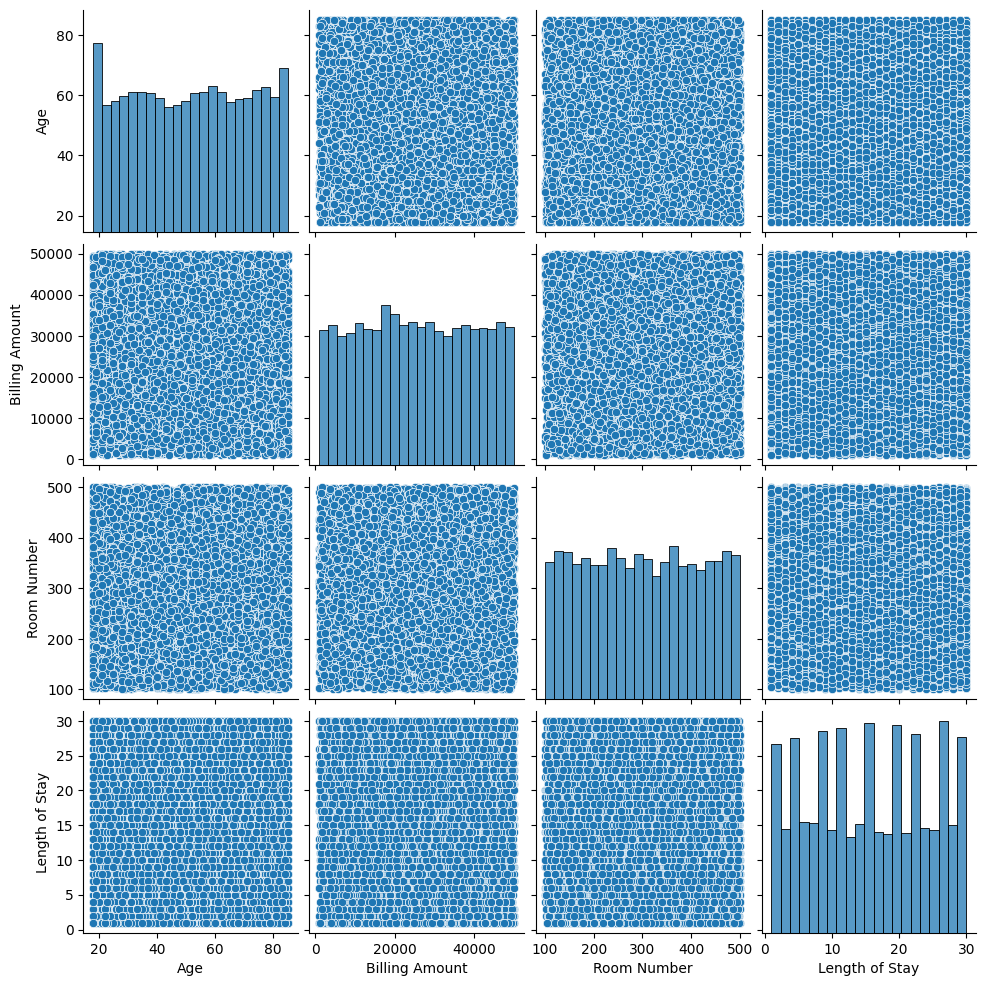

In [139]:
sns.pairplot(df)

**Distribución del precio (la cantidad prevista)**

<Axes: ylabel='Frequency'>

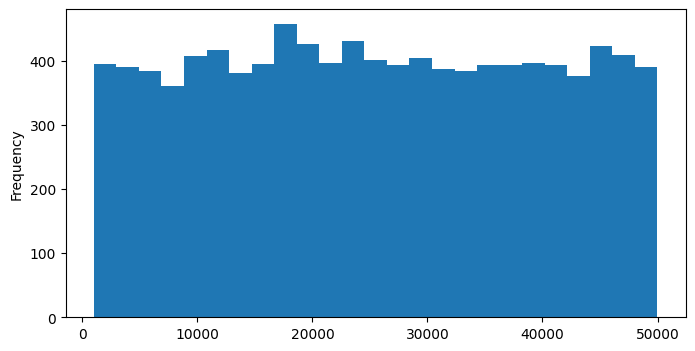

In [46]:
df['Billing Amount'].plot.hist(bins=25,figsize=(8,4))

<Axes: ylabel='Density'>

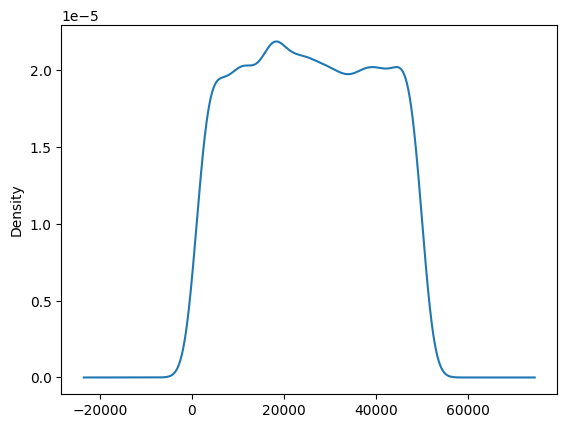

In [37]:
df['Billing Amount'].plot.density()

**Matriz de correlación y heatmap**

In [140]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.corr()

,Age,Billing Amount,Room Number,Length of Stay
Age,1.000000,-0.009483,-0.005371,0.009111
Billing Amount,-0.009483,1.000000,-0.006160,-0.013507
Room Number,-0.005371,-0.006160,1.000000,0.009610
Length of Stay,0.009111,-0.013507,0.009610,1.000000


<Axes: >

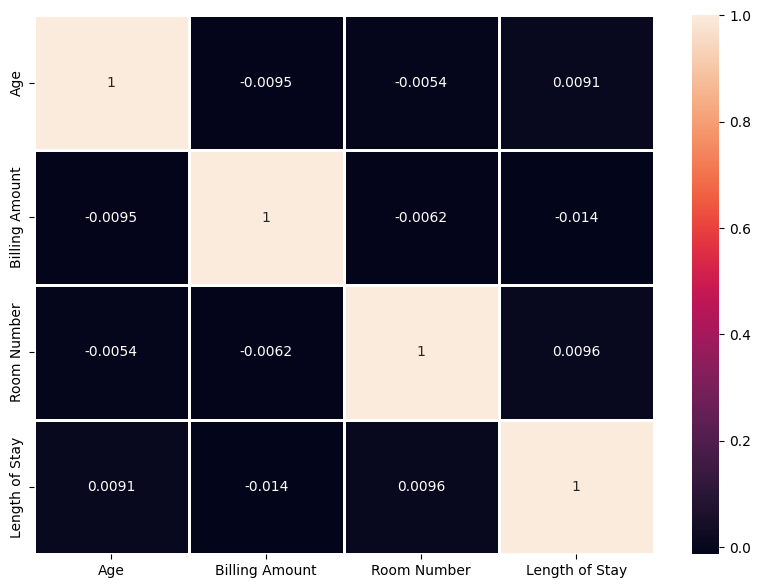

In [177]:
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(),annot=True,linewidths=2)

### Conjuntos de características y variables

**Haga una lista de los nombres de las columnas del dataframe**

In [107]:
l_column = list(df.columns) # Haciendo una lista de las columnas
len_feature = len(l_column) # Longitud de la lista de vectores de columna
l_column

['Name',
 'Age',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Billing Amount',
 'Room Number',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results',
 'Length of Stay']

**Coloque todas las características numéricas en X y el precio en y, ignore la dirección, que es una cadena para la regresión lineal**

In [143]:
# Seleccionar solo las variables que lógicamente afectarían el precio (filtrando el ruido)
features = [
    'Age',
    'Gender',
    'Length of Stay',
    'Medical Condition',
    'Admission Type',
    'Medication'
]

X = df[features].copy()
y = df['Billing Amount']

# One-Hot Encoding (con dtype=int para que statsmodels no lance error)
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [144]:
print("Tamaño de Características:",X.shape)
print("Tamaño de Variable Objetivo:",y.shape)

Tamaño de Características: (10000, 14)
Tamaño de Variable Objetivo: (10000,)


In [178]:
X.head()

,Age,Length of Stay,Gender_Male,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Admission Type_Emergency,Admission Type_Urgent,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,81,14,0,0,0,1,0,0,0,0,0,0,0,0
1,35,14,1,1,0,0,0,0,1,0,0,1,0,0
2,61,30,1,0,0,0,0,1,1,0,0,1,0,0
3,49,1,1,1,0,0,0,0,0,1,0,0,0,1
4,51,24,1,0,0,0,0,0,0,1,0,0,1,0


In [111]:
y.head()

,Billing Amount
0,37490.983364
1,47304.064845
2,36874.896997
3,23303.322092
4,18086.344184


### División de entrenamiento-prueba

**Importamos la función train_test_split de scikit-learn**

In [146]:
from sklearn.model_selection import train_test_split

**Creamos los conjuntos de entrenamiento X y de prueba y en un comando usando una proporción de división y una semilla aleatoria**

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

**Verifique el tamaño y la forma de las divisiones de entrenamiento/prueba (debe estar en la proporción según el parámetro test_size anterior)**

In [148]:
print("Tamaño del conjunto de características del entrenamiento:",X_train.shape)
print("Tamaño del conjunto de características de prueba:",X_test.shape)
print("Tamaño de la variable objetivo del entrenamiento:",y_train.shape)
print("Tamaño de la variable objetivo de prueba:",y_test.shape)

Tamaño del conjunto de características del entrenamiento: (8000, 14)
Tamaño del conjunto de características de prueba: (2000, 14)
Tamaño de la variable objetivo del entrenamiento: (8000,)
Tamaño de la variable objetivo de prueba: (2000,)


### Ajuste y entrenamiento del modelo

**Importamos el estimador de modelo de regresión lineal de scikit-learn e lo instanciamos**

In [172]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

print("=== MÉTRICAS PRINCIPALES ===")
print("R2 Score (Varianza explicada):", round(metrics.r2_score(y_test, y_pred_test), 4))
print("MAE (Error absoluto medio):", round(metrics.mean_absolute_error(y_test, y_pred_test), 2))
print("RMSE (Raíz del error cuadrático medio):", round(np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)), 2))

=== MÉTRICAS PRINCIPALES ===
R2 Score (Varianza explicada): -0.001
MAE (Error absoluto medio): 12067.2
RMSE (Raíz del error cuadrático medio): 14049.9


**Ajustamos el modelo al propio objeto instanciado**

**Verificamos la intercepción y los coeficientes y los colocamos en un DataFrame**

In [150]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\n=== COEFICIENTES DEL MODELO ===\n")
print(coef_df)

print("\nIntercepto del modelo:\n", model.intercept_)


=== COEFICIENTES DEL MODELO ===

                          Variable  Coeficiente
5       Medical Condition_Diabetes  1020.907820
4         Medical Condition_Cancer   582.459553
6   Medical Condition_Hypertension   519.053966
11              Medication_Lipitor   488.033939
3         Medical Condition_Asthma   400.026166
9            Admission Type_Urgent   279.765701
2                      Gender_Male   177.196862
7        Medical Condition_Obesity   162.337926
10            Medication_Ibuprofen    46.045967
0                              Age    -7.401735
1                   Length of Stay   -18.730297
13           Medication_Penicillin  -339.906772
12          Medication_Paracetamol  -420.595800
8         Admission Type_Emergency -1227.796960

Intercepto del modelo:
 25982.705196819756


### Cálculo de errores estándar y estadística t para los coeficientes

In [151]:
cdf = pd.DataFrame({
    'Coefficients': model.coef_
}, index=X_train.columns)

In [152]:
n = X_train.shape[0]
k = X_train.shape[1]
dfN = n - k

# 👇 AQUÍ estaba el error
train_pred = model.predict(X_train)

train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

se = np.zeros(k)

for i in range(k):
    Xi = X_train.iloc[:, i]
    r = (sum_error / dfN)
    r = r / np.sum((Xi - Xi.mean())**2)
    se[i] = np.sqrt(r)

cdf['Standard Error'] = se
cdf['t-statistic'] = cdf['Coefficients'] / cdf['Standard Error']

cdf

,Coefficients,Standard Error,t-statistic
Age,-7.401735,8.028887,-0.921888
Length of Stay,-18.730297,18.279880,-1.024640
Gender_Male,177.196862,314.413958,0.563578
Medical Condition_Asthma,400.026166,419.209630,0.954239
Medical Condition_Cancer,582.459553,417.257069,1.395925
Medical Condition_Diabetes,1020.907820,427.162350,2.389976
Medical Condition_Hypertension,519.053966,420.076311,1.235618
Medical Condition_Obesity,162.337926,424.787809,0.382162
Admission Type_Emergency,-1227.796960,331.744234,-3.701035
Admission Type_Urgent,279.765701,332.279948,0.841958


In [153]:
print("Por lo tanto, las características organizadas en orden de importancia para predecir el precio de la vivienda\n",'-'*90,sep='')
l=list(cdf.sort_values('t-statistic',ascending=False).index)
print(' > \n'.join(l))

Por lo tanto, las características organizadas en orden de importancia para predecir el precio de la vivienda
------------------------------------------------------------------------------------------
Medical Condition_Diabetes > 
Medical Condition_Cancer > 
Medication_Lipitor > 
Medical Condition_Hypertension > 
Medical Condition_Asthma > 
Admission Type_Urgent > 
Gender_Male > 
Medical Condition_Obesity > 
Medication_Ibuprofen > 
Medication_Penicillin > 
Age > 
Length of Stay > 
Medication_Paracetamol > 
Admission Type_Emergency


In [155]:
# Resumen estadístico detallado con Statsmodels
X_train_sm = sm.add_constant(X_train)
sm_model = sm.OLS(y_train, X_train_sm).fit()
print("\n=== RESUMEN ESTADÍSTICO PARA EL PROFESOR ===")
print(sm_model.summary())


=== RESUMEN ESTADÍSTICO PARA EL PROFESOR ===
                            OLS Regression Results                            
Dep. Variable:         Billing Amount   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.011
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0137
Time:                        17:09:57   Log-Likelihood:                -87753.
No. Observations:                8000   AIC:                         1.755e+05
Df Residuals:                    7985   BIC:                         1.756e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

**Diagrama de dispersión (Scatterplot) del precio previsto y el conjunto de prueba y para ver si los datos caen en una línea recta de 45 grados**

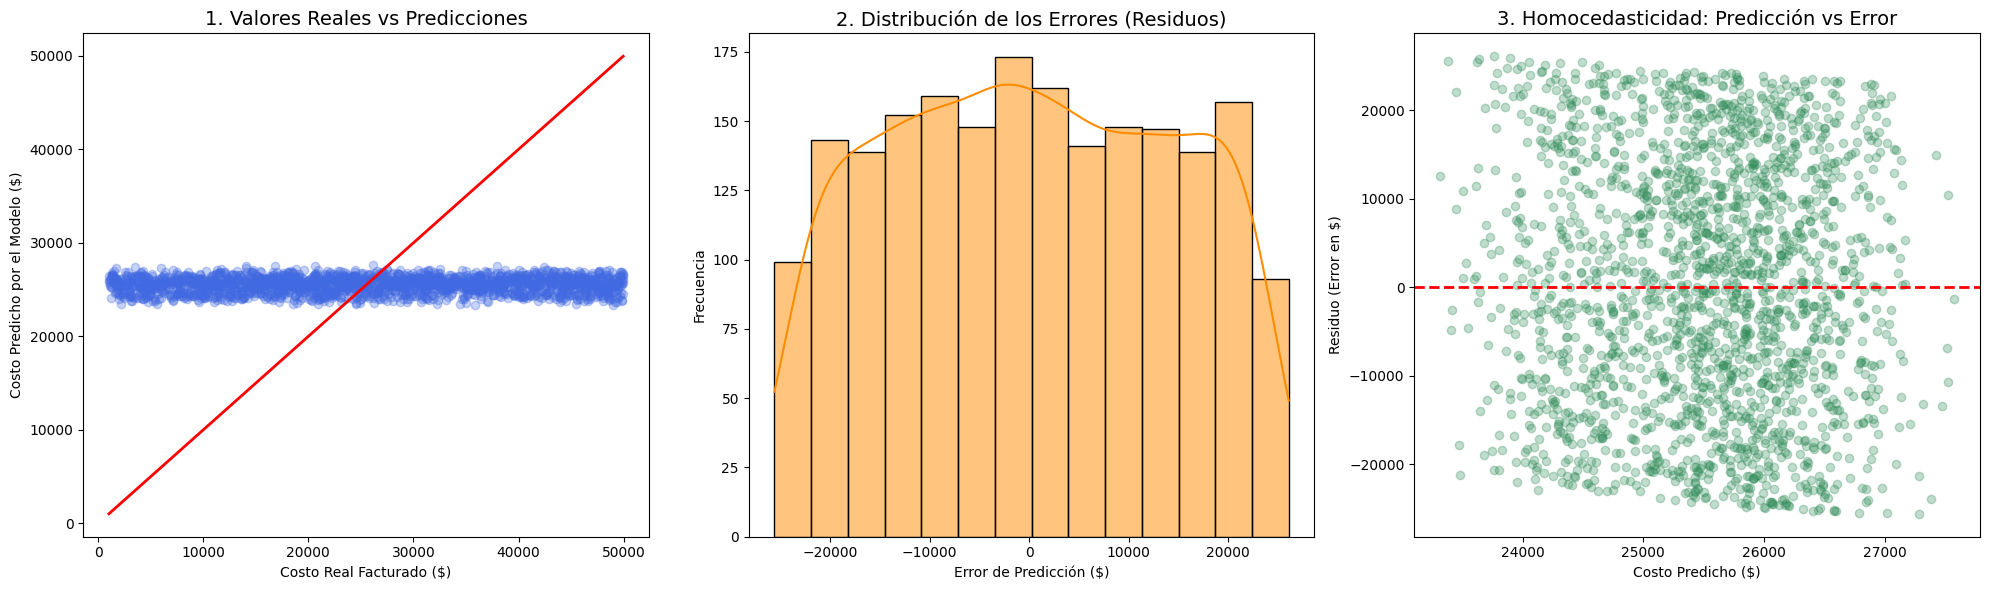

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Real vs Predicho
axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
axes[0].set_title("1. Valores Reales vs Predicciones", fontsize=14)
axes[0].set_xlabel("Costo Real Facturado ($)")
axes[0].set_ylabel("Costo Predicho por el Modelo ($)")

# Gráfico 2: Histograma de Residuos
residuos = y_test - y_pred_test
sns.histplot(residuos, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title("2. Distribución de los Errores (Residuos)", fontsize=14)
axes[1].set_xlabel("Error de Predicción ($)")
axes[1].set_ylabel("Frecuencia")

# Gráfico 3: Homocedasticidad
axes[2].scatter(y_pred_test, residuos, alpha=0.3, color='seagreen')
axes[2].axhline(y=0, color='red', linestyle='--', lw=2)
axes[2].set_title("3. Homocedasticidad: Predicción vs Error", fontsize=14)
axes[2].set_xlabel("Costo Predicho ($)")
axes[2].set_ylabel("Residuo (Error en $)")

plt.tight_layout()
plt.show()


**Interpretación de Resultados:**

El resultado de la regresión lineal dio un R^2 = 0.004, lo cual es un resultado extremadamente bajo. Esto nos indica que las variables utilizadas tienen poca o ninguna relación con el Billing Amount. Esto también se demuestra con los coeficientes asi como el error estandar, donde los resultados son valores muy altos, que afectan en gran medida las predicciones.

Como se puede observar en el primer gráfico, la nube de color azul son los valores obtenidos de Billing Amount, mientras que la línea roja es la predicción después de realizar la regresión lineal. En ese gráfico, en casi ningún punto la linea roja logra interceptarse con la nube azul, lo que indica que no hay relación entre la predicción y los valores obtenidos. Esto nos indica que la regresión lineal no fue la adecuada y que no hay relación entre las variables.

Por otro lado, el segundo gráfico nos muestra la normalidad de los errores, aca también se puede observar que la regresión no fue efectiva, ya que el error de predicción va desde -20000 a 20000, lo que indica que la posibilidad de errar en la predicción es de 20 000, lo que es un valor extremadamente alto para un error en relación a los Billing Amounts que se tienen.

Finalmente, el último gráfico muestra la homesteosidad, donde se observa que los precios predichos solo van de 24 000 a 27 000, lo que indica que el modelo de regresión lineal solo logra predecir entre ese rango mínimo, mientras que los valores esperados deberían ir en un rango mucho más amplio.

Después de analizar los gráficos se llega a la conclusión de que la regresión lineal no sirve como modeo para intentar predecir los posibles valores del Billing amount, ya que no hay relación alguna entre las variables utilizadas y la variable del precio. Aunque se intentó filtrar las variables para solo utilizar las más adecuadas.

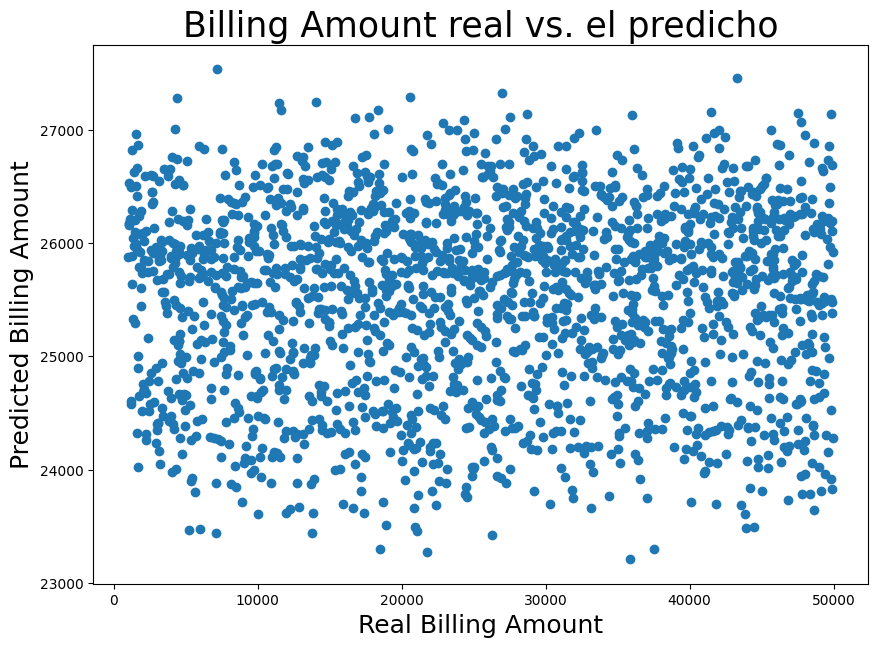

In [157]:
plt.figure(figsize=(10,7))
plt.title("Billing Amount real vs. el predicho",fontsize=25)
plt.xlabel("Real Billing Amount",fontsize=18)
plt.ylabel("Predicted Billing Amount", fontsize=18)
plt.scatter(x=y_test,y=predictions)

**Visualizamos el histograma de los residuos, es decir, errores predichos (se espera un patrón distribuido normalmente)**

/tmp/ipykernel_11491/1939217874.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([y_test-predictions])


<Axes: title={'center': 'Histograma de residuos para verificar la normalidad '}, xlabel='Residuos', ylabel='Densidad del kernel'>

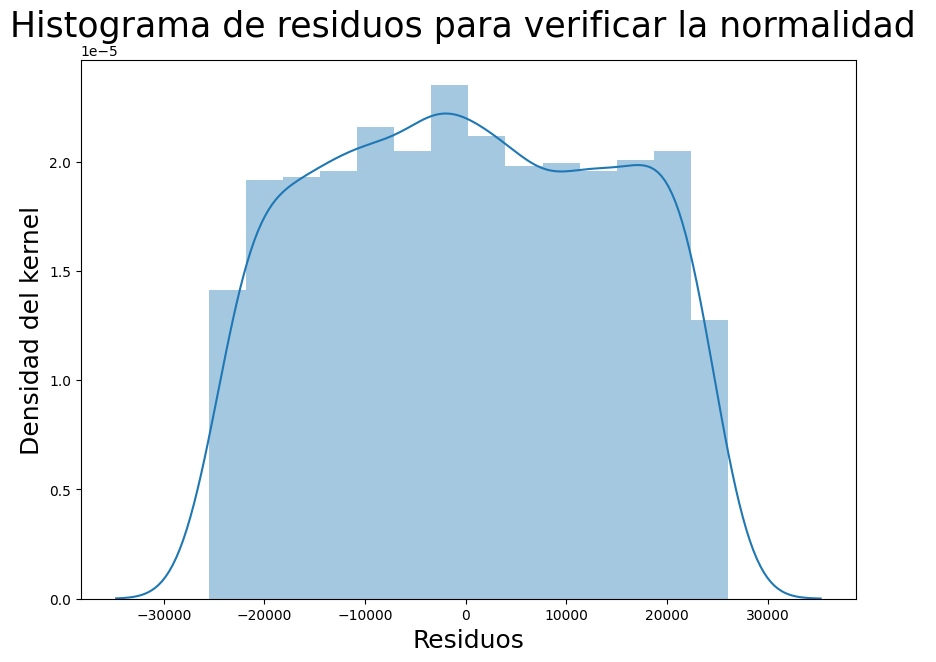

In [158]:
plt.figure(figsize=(10,7))
plt.title("Histograma de residuos para verificar la normalidad ",fontsize=25)
plt.xlabel("Residuos",fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.distplot([y_test-predictions])

**Diagrama de dispersión de residuos y valores predichos (Homoscedasticidad)**


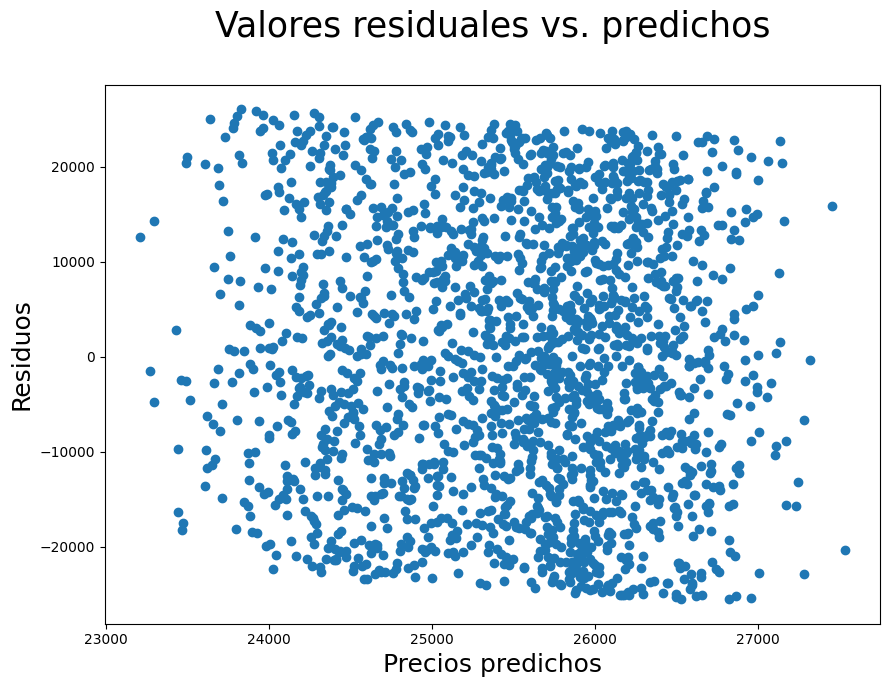

In [176]:
plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. predichos\n",fontsize=25)
plt.xlabel("Precios predichos",fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions,y=y_test-predictions)